<h1 style="color:#8B0000; text-align:center; font-weight:bold;">DATASCI 530 Assignment 2</h1>
<h1 style="color:#8B0000; text-align:center; font-weight:bold;">Formula 1</h1>
<p style="color:#8B0000; text-align:center; font-size:18px;">Maxine Hakimi-Bulson</p>

<h2 style="color:#8B0000;">Formula 1</h2>

Formula 1 (F1) is an international car-racing competition. Multiple races take place every season, and drivers compete for constructors, or their teams. Each driver earns points individually from each race, and their points accumulate over the season. The constructor's  points are a combination of all of their drivers' points earned during the season.

<h2 style="color:#8B0000;">Summary of Findings</h2>

This analysis examined Formula 1 constructor performance and Ferrari's drivers and race outcomes between 1981 and 2020. 

Here are the main findings:

- From **1981–2020**, the three constructors with the most total points were **Ferrari, Mercedes, and McLaren**, respectively.

- From **2001–2020**, the three constructors with the most total points were **Ferrari, Mercedes, and Red Bull**, respectively.

- **Ferrari had 25 different drivers** compete for the team between 1981 and 2020.

- From 1981-2020, Ferrari earned its **highest total number of points in 2018**, while its **highest number of race wins occurred in 2002 and 2004**. 

- The most common reasons Ferrari drivers did not finish races included **engine issues, collisions, spinning off, accidents, and gearbox issues**.

<h2 style="color:#8B0000;">Loading Libraries and Data</h2>


First we will load the necessary libraries and f1 datasets to complete our analyses.

In [31]:
# Import pandas, numpy, and matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# Read and store the f1 datasets
circuits = pd.read_csv("data_raw/circuits.csv")
constructor_results = pd.read_csv("data_raw/constructor_results.csv")
constructor_standings = pd.read_csv("data_raw/constructor_standings.csv")
constructors = pd.read_csv("data_raw/constructors.csv")
driver_standings = pd.read_csv("data_raw/driver_standings.csv")
drivers = pd.read_csv("data_raw/drivers.csv")
lap_times = pd.read_csv("data_raw/lap_times.csv")
pit_stops = pd.read_csv("data_raw/pit_stops.csv")
qualifying = pd.read_csv("data_raw/qualifying.csv")
races = pd.read_csv("data_raw/races.csv")
results = pd.read_csv("data_raw/results.csv")
seasons = pd.read_csv("data_raw/seasons.csv")
status = pd.read_csv("data_raw/status.csv")

<h2 style="color:#8B0000;">Inquiry & Analysis</h2>

<h3 style="color:#8B0000;">(a) Highest point-earning constructors and comparison with average (1981-2020) </h3>
<h4 style="color:#8B0000;">Creating the merged dataset for analysis (1981-2020) </h4>

In order to analyze constructors and points earned from 1981-2020, I need the points earned by each constructor, the year, and constructor name. I will merge three datasets: `constructor_results`, `races`, and `constructors`. I chose to utilize `constructor_results` rather than use `constructor_standings` because the latter's `point` variable is an accumulation of points at different times over the season, making it more confusing for analysis. In `constructor_results`, the `point` variable records the points earned for each constructor from each race, without accumulating it as time goes on. I will also need variables `raceId` and `constructorId` in order to conduct the merge with the other two datasets. I will be needing the `year` variable from the `races` dataset, and `name` from the `constructors` dataset to know the names of each constructor. I will merge these datasets using `raceId` and `constructorId`, then filter for years between 1981-2020.

In [33]:
# Merge constructor results with races to get the year
constructor_merged = constructor_results[
    ['raceId', 'constructorId', 'points']
].merge(
    races[['raceId', 'year']],
    on='raceId'
)

# Merge with constructors to get the constructor name
constructor_merged = constructor_merged.merge(
    constructors[['constructorId', 'name']],
    on='constructorId'
)

# Quality checks to ensure datasets merged successfully
#display(constructor_merged)
#print(constructor_merged.shape)
#print(constructor_merged.isna().sum())
#print(constructor_merged.nunique())
#print(constructor_results.shape)
#print(constructor_merged.shape)

# Filter for years 1981 through 2020
constructor_merged_tf = constructor_merged[
    (constructor_merged['year'] >= 1981) &
    (constructor_merged['year'] <= 2020)
]

Constructor,Total Points,Average Across Constructors,Points Above Average
Ferrari,"7,374.0",532.24,"6,841.76"
Mercedes,"5,685.0",532.24,"5,152.76"
McLaren,"5,229.5",532.24,"4,697.26"


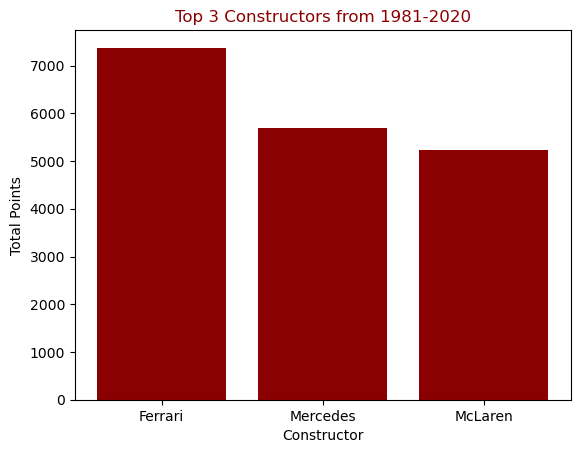

In [37]:
# Add up race points for each constructor
total_points_constructor = (
    constructor_merged_tf.groupby('name')['points'].sum().reset_index()
)

# Calculate the average total points across all constructors
average_points_constructor = total_points_constructor['points'].mean()

# Compare each constructor to the average
total_points_constructor.loc[:, 'average_points'] = average_points_constructor
total_points_constructor.loc[:, 'points_above_average'] = (
    total_points_constructor['points'] - average_points_constructor
)

# Sort constructors from highest to lowest points
total_points_constructor = total_points_constructor.sort_values(
    by='points', ascending=False
).reset_index(drop=True)

# Select the top three constructors
highest_points_constructor = total_points_constructor.loc[0:2]

# Rename columns for the final table
highest_points_constructor = highest_points_constructor.rename(columns={
    'name': 'Constructor',
    'points': 'Total Points',
    'average_points': 'Average Across Constructors',
    'points_above_average': 'Points Above Average'
})

# Display as a formatted table
display(
    highest_points_constructor.style.format({
        'Total Points': '{:,.1f}',
        'Average Across Constructors': '{:,.2f}',
        'Points Above Average': '{:,.2f}'
    }).hide(axis='index').set_caption('Top 3 Constructors from 1981–2020')
)

# Display bar chart
plt.bar(
    highest_points_constructor['Constructor'],
    highest_points_constructor['Total Points'],
    color='darkred'
)

plt.title('Top 3 Constructors from 1981-2020', color='darkred')
plt.xlabel('Constructor')
plt.ylabel('Total Points')

plt.show()

<h4 style="color:#8B0000;">(a) Analysis </h4>

Ferrari, Mercedes, and McLaren earned the most points between 1981 and 2020. They earned a total of 7374, 5685, and 5229.5 points respectively. The top three constructors all earned well above the average points across constructors from 1981-2020, which was 532.24. Ferrari scored approximately 6850 more points than the average, Mercedes earned approximately 5150 points above the average, and McLaren scored approximately 4700 points above the average points across constructors from 1981-2020.

<h3 style="color:#8B0000;">(b) Highest point-earning constructors and comparison with average (2001-2020) </h3>

Since part (b) is using the same information we obtained from part (a) but from 2001-2020 rather than from 1981-2020, I will be using the same dataset, `constructor_merged` and filter `year` from 2001-2020.

Constructor,Total Points,Average Across Constructors,Points Above Average
Ferrari,"5,862.0",786.01,"5,075.99"
Mercedes,"5,685.0",786.01,"4,898.99"
Red Bull,"5,043.5",786.01,"4,257.49"


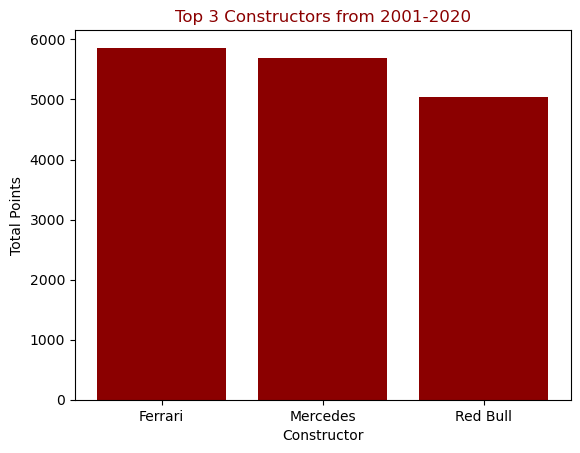

In [38]:
# Filter for years 2001 through 2020
constructor_merged_tf_b = constructor_merged[
    (constructor_merged['year'] >= 2001) &
    (constructor_merged['year'] <= 2020)
]

# Quality checks
#print(constructor_merged_tf_b.shape)
#print(constructor_merged_tf_b.isna().sum())
#print(constructor_merged_tf_b.nunique())

# Add up race points for each constructor
total_points_constructor_b = (
    constructor_merged_tf_b.groupby('name')['points'].sum().reset_index()
)

# Calculate the average total points across all constructors
average_points_constructor_b = total_points_constructor_b['points'].mean()

# Compare each constructor to the average
total_points_constructor_b.loc[:, 'average_points'] = average_points_constructor_b
total_points_constructor_b.loc[:, 'points_above_average'] = (
    total_points_constructor_b['points'] - average_points_constructor_b
)

# Sort constructors from highest to lowest points
total_points_constructor_b = total_points_constructor_b.sort_values(
    by='points', ascending=False
).reset_index(drop=True)

# Select the top three constructors
highest_points_constructor_b = total_points_constructor_b.loc[0:2]

# Rename columns for the final table
highest_points_constructor_b = highest_points_constructor_b.rename(columns={
    'name': 'Constructor',
    'points': 'Total Points',
    'average_points': 'Average Across Constructors',
    'points_above_average': 'Points Above Average'
})

# Display the pretty table
display(
    highest_points_constructor_b.style.format({
        'Total Points': '{:,.1f}',
        'Average Across Constructors': '{:,.2f}',
        'Points Above Average': '{:,.2f}'
    }).hide(axis='index').set_caption('Top 3 Constructors from 2001–2020')
)

# Display bar chart
plt.bar(
    highest_points_constructor_b['Constructor'],
    highest_points_constructor_b['Total Points'],
    color='darkred'
)

plt.title('Top 3 Constructors from 2001-2020', color='darkred')
plt.xlabel('Constructor')
plt.ylabel('Total Points')

plt.show()

<h4 style="color:#8B0000;">(b) Analysis </h4>

Ferrari, Mercedes, and Red Bull earned the most points between 2001 and 2020. They earned a total of 5862, 5685, and 5043.5 points respectively. The top three constructors all earned well above the average points across constructors from 2001-2020, which was 786.01. Ferrari and Mercedes scored approximately 5000 more points than the average, and Red Bull scored approximately 4200 points above the average points across constructors from 2001-2020.

<h3 style="color:#8B0000;">(c) Change in rankings over time</h3>


Across the two time periods, the average points across constructors had increased by approximately 350 points from the 1981-2020 timeframe to the 2001-2020 timeframe, implying that the average points earned across constructors from 1981-2000 was much lower than the average points earned from 2001-2020.

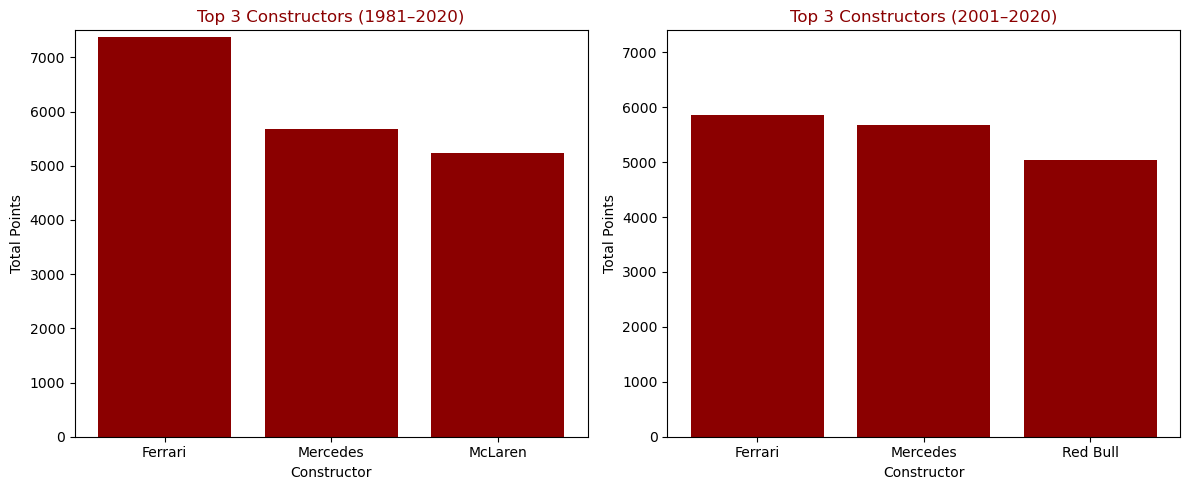

In [42]:
# Create two bar charts side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) bar chart 1981-2020
axes[0].bar(
    highest_points_constructor['Constructor'],
    highest_points_constructor['Total Points'],
    color='darkred'
)

axes[0].set_title('Top 3 Constructors (1981–2020)', color='darkred')
axes[0].set_xlabel('Constructor')
axes[0].set_ylabel('Total Points')
axes[0].set_ylim(0, 7500)

# (b) bar chart 2001-2020
axes[1].bar(
    highest_points_constructor_b['Constructor'],
    highest_points_constructor_b['Total Points'],
    color='darkred'
)

axes[1].set_title('Top 3 Constructors (2001–2020)', color='darkred')
axes[1].set_xlabel('Constructor')
axes[1].set_ylabel('Total Points')
axes[1].set_ylim(0, 7400)

plt.tight_layout()
plt.show()

It is noteworthy to mention how Ferrari and Mercedes have remained the first and second place constructors over time. Yet, the number of points earned by Mercedes in both timeframes is the same, meaning the Mercedes constructor had not started earning points until the 2001-2020 timeframe. Mercedes did not earn any points from 1981-2000. 

To continue, we notice that from 1981-2020, McLaren (5229.5 points) is the third place constructor based on points earned, yet Red Bull (5043.5 points) takes third place between 2001-2020. This is interesting since McLaren has earned more points than Red Bull, but it was over a longer period of time. So, McLaren earned the majority of their points before 2001, explaining why Red Bull has taken third place as the top 3 constructor from 2001-2020.

<h3 style="color:#8B0000;">(d) Ferrari drivers count (1981-2020)</h3>
<h4 style="color:#8B0000;">Creating the merged dataset for analysis (Ferrari, 1981-2020) </h4>

To determine the number of different drivers Ferrari had between 1981 and 2020, I need to identify the drivers, constructors, and year. The `results` dataset contains `driverId`, `raceId`, and `constructorId`, which allows the race results to be connected to the `races` and `constructors` datasets. The `races` dataset includes `year`, while the `constructors` dataset has `name`, which I will use to identify Ferrari. I will also keep the `points`, `position`, and `statusId` variables from the `results` dataset for analyses in future sections.


In [46]:
# Merge results with races to add the year
ferrari_merged = results[
    ['raceId', 'driverId', 'constructorId', 'points', 'position', 'statusId']
].merge(
    races[['raceId', 'year']],
    on='raceId'
)

# Merge with constructors to add the constructor name
ferrari_merged = ferrari_merged.merge(
    constructors[['constructorId', 'name']],
    on='constructorId'
)

# Filter for Ferrari and years 1981 through 2020
ferrari = ferrari_merged[
    (ferrari_merged['name'] == 'Ferrari') &
    (ferrari_merged['year'] >= 1981) &
    (ferrari_merged['year'] <= 2020)
]

# Quality checks
#print(ferrari.shape)
#print(ferrari.isna().sum())
#print(ferrari.nunique())

# Count the number of unique Ferrari drivers
number_ferrari_drivers = ferrari['driverId'].nunique()

print("Number of Ferrari drivers from 1981-2020:", number_ferrari_drivers)

Number of Ferrari drivers from 1981-2020: 25


Between 1981 and 2020, Ferrari had 25 different drivers.

<h3 style="color:#8B0000;">(e) Ferrari's best year (1981-2020)</h3>

Ferrari's "best year" can be determined in multiple ways. Therefore, I will calculate both total `points` and number of race `wins` for each year between 1981 and 2020. I will use the `ferrari` dataset created in part (d).


In [56]:
# Find Ferrari's total points for each year
ferrari_yearly_points = (
    ferrari.groupby('year')['points'].sum().reset_index()
)

# Sort years from highest to lowest total points
ferrari_yearly_points = ferrari_yearly_points.sort_values(
    by='points', ascending=False
).reset_index(drop=True)

# Rename columns
ferrari_yearly_points = ferrari_yearly_points.rename(columns={
    'year': 'Year',
    'points': 'Points'
})

# Display the top five years by points
display(
    ferrari_yearly_points.head().style.format({
        'Points': '{:,.1f}'
    }).hide(axis='index').set_caption(
        'Ferrari Points (1981-2020)'
    )
)


# Find Ferrari's race wins
ferrari_wins = ferrari[ferrari['position'] == '1']

# Count the number of wins in each year
ferrari_yearly_wins = (
    ferrari_wins.groupby('year').size().reset_index(name='wins')
)

# Sort years from highest to lowest number of wins
ferrari_yearly_wins = ferrari_yearly_wins.sort_values(
    by='wins', ascending=False
).reset_index(drop=True)

# Rename columns
ferrari_yearly_wins = ferrari_yearly_wins.rename(columns={
    'year': 'Year',
    'wins': 'Wins'
})

# Display the top five years by wins
display(
    ferrari_yearly_wins.head().style
    .hide(axis='index')
    .set_caption('Ferrari Race Wins (1981-2020)')
)


# Quality checks
#print(ferrari_yearly_points.shape)
#print(ferrari_yearly_points.isna().sum())
#print(ferrari_yearly_wins.shape)
#print(ferrari_yearly_wins.isna().sum())

Year,Points
2018,571.0
2017,522.0
2019,504.0
2015,428.0
2012,400.0


Year,Wins
2002,15
2004,15
2000,10
2007,9
2006,9


The best year for Ferrari between 1981 and 2020 in terms of points earned was the year 2018, having earned 571 points within that one year.

Ferrari's best year based on number of wins was 2002 and 2004, having earned 15 wins both years.

<h2 style="color:#8B0000;">New Insights</h2>

<h3 style="color:#8B0000;">(f) Computing additional figures</h3>
<h4 style="color:#8B0000;">How many finishes has Ferrari had from 1981-2020? For the ones that did not finish, what were the most frequent reasons for not finishing?</h4>

To answer these questions, I will use the `ferrari` dataset created in part (d). The `statusId` variable will be merged with the `status` dataset to learn finishing status. I will count the frequency of each status and discover the most frequent race outcomes, and then display the most common reasons Ferrari drivers did not finish a race. To show only the reasons for not finishing I manually exclude the "finish" status or "+1/+2 laps" status.

Status,Count
Finished,856
+1 Lap,117
Engine,75
Collision,56
Spun off,33
Accident,33
Gearbox,28
Suspension,23
Turbo,20
Electrical,17


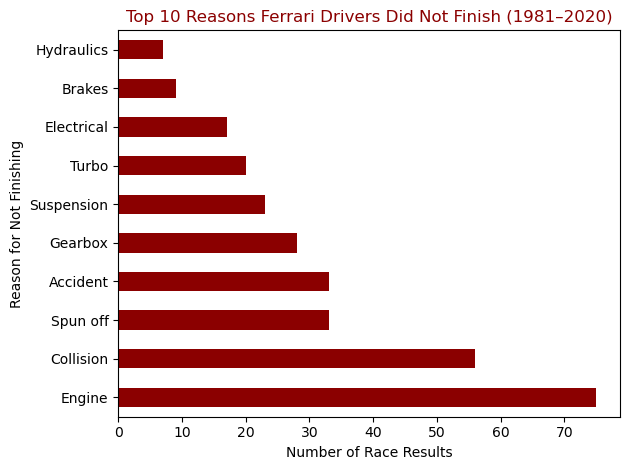

In [54]:
# Add finishing status information to the Ferrari dataset
ferrari_status = ferrari.merge(
    status[['statusId', 'status']],
    on='statusId'
)

# Quality checks
#print(ferrari_status.shape)
#print(ferrari_status.isna().sum())
#print(ferrari_status['status'].nunique())

# Count each Ferrari finishing status
status_counts = ferrari_status['status'].value_counts().reset_index()

# Rename columns
status_counts.columns = ['Status', 'Count']

# Display the most common statuses
#display(status_counts.head(20))

# Select the top 10 finishing statuses
top_10_status = status_counts.head(10)

# Display the pretty table
display(
    top_10_status.style
    .hide(axis='index')
    .set_caption('Top 10 Ferrari Driver Finishing Statuses (1981–2020)')
)

# Remove statuses that represent completed or classified finishes
not_finished = status_counts[
    (status_counts['Status'] != 'Finished') &
    (status_counts['Status'] != '+1 Lap') &
    (status_counts['Status'] != '+2 Laps')
]

# Display the top 10 reasons for not finishing
#display(not_finished.head(10))

# Select the top 10 reasons for not finishing
top_10_dnf = not_finished.head(10)

# Display bar chart
top_10_dnf.plot(
    kind='barh',
    x='Status',
    y='Count',
    legend=False,
    color='darkred'
)

plt.title('Top 10 Reasons Ferrari Drivers Did Not Finish (1981–2020)', color='darkred')
plt.xlabel('Number of Race Results')
plt.ylabel('Reason for Not Finishing')

plt.tight_layout()
plt.show()

<h3 style="color:#8B0000;">(g) Valuable insight learned from additional figures</h3>

From this bar chart, we learn that the top 10 reasons ferrari drivers from 1981-2020 did not finish the race was due to engine issues, collisions, the car spun off, there was an accident, or issues with their gearbox, suspension, turbo, electrical, brakes, or hydraulics.